# Word2Vec Results Demo

This notebook is for **showing the learned embeddings only**.  
It does **not** include training. It focuses on:

- nearest neighbors
- word analogy
- similarity sanity checks
- PCA
- t-SNE
- cosine similarity heatmap

You can choose where to load `W_center.npy` from in the configuration cell below.


In [1]:
from pathlib import Path
PROJECT_ROOT = Path(".").resolve()
# Option A: point to a run directory, then let the notebook resolve checkpoint paths

RUN_DIR = PROJECT_ROOT / "checkpoints" / "20260315_231058"
CHECKPOINT_SUBDIR = "final"   # "final" or "latest"

if not RUN_DIR.exists():
    raise FileNotFoundError(
        f"RUN_DIR does not exist: {RUN_DIR}\n"
        "Please update RUN_DIR to a valid checkpoint run folder."
    )

# Option B: directly point to checkpoint files (overrides RUN_DIR if not None)
W_CENTER_PATH = None
W_CONTEXT_PATH = None

# Which embedding should be used for analysis?
# Options: "center", "context", "average"
EMBEDDING_SOURCE = "average"

In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    import sklearn  # noqa: F401
except Exception as e:
    raise ImportError("This notebook needs scikit-learn. Install it with: pip install scikit-learn") from e

# =========================
# Configuration
# =========================

# How to load vocab?
# Options: "rebuild", "json", "npy", "pkl", "none"
VOCAB_MODE = "json"
VOCAB_PATH = RUN_DIR / "vocab.json"

# If VOCAB_MODE == "rebuild", whether to reuse settings from run_config.json
USE_RUN_CONFIG_FOR_VOCAB = True

# Demo settings
TOP_K = 10
PCA_WORDS = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "paris", "france", "berlin", "germany",
    "london", "england", "rome", "italy",
    "cat", "dog", "horse", "bird",
    "car", "train", "plane", "city",
    "music", "science", "art", "history",
]
TSNE_MAX_WORDS = 250
TSNE_RANDOM_STATE = 42

SHOW_LOSS_CURVE = True

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = C:\Users\User1\OneDrive - TU Eindhoven\Job\JetBrains\Hallucination Detection


Load helper utilities from the companion file next to this notebook.

In [3]:
# =========================
# Keeping them outside the main demo flow makes the notebook easier to present.
# =========================
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from src.eval.demo_helpers import (
    resolve_checkpoint_paths,
    load_run_config,
    load_numpy_embeddings,
    l2_normalize_rows,
    maybe_load_vocab,
    nearest_neighbors,
    analogy,
    similarity_table,
    plot_loss_if_available,
    collect_existing_words,
    plot_pca,
    plot_tsne,
    plot_similarity_heatmap,
    maybe_pick_default_words,
)

Load embeddings and vocab (code hidden)

In [4]:
# =========================
# Load embeddings and vocab
# =========================

W_CENTER_PATH_RESOLVED, W_CONTEXT_PATH_RESOLVED = resolve_checkpoint_paths(
    run_dir=RUN_DIR,
    checkpoint_subdir=CHECKPOINT_SUBDIR,
    w_center_path=W_CENTER_PATH,
    w_context_path=W_CONTEXT_PATH,
)

if not W_CENTER_PATH_RESOLVED.exists():
    raise FileNotFoundError(
        f"Cannot find W_center.npy at: {W_CENTER_PATH_RESOLVED}\n"
        "Please update RUN_DIR or W_CENTER_PATH in the configuration cell."
    )

run_config = load_run_config(RUN_DIR)
W_center, W_context, EMB = load_numpy_embeddings(
    W_CENTER_PATH_RESOLVED,
    W_CONTEXT_PATH_RESOLVED,
    embedding_source=EMBEDDING_SOURCE,
)
EMB_NORM = l2_normalize_rows(EMB)

word2id, id2word = maybe_load_vocab(
    vocab_mode=VOCAB_MODE,
    vocab_path=VOCAB_PATH,
    project_root=PROJECT_ROOT,
    run_config=run_config,
    use_run_config_for_vocab=USE_RUN_CONFIG_FOR_VOCAB,
)

print("Loaded embedding matrices:")
print(f"  W_center: {W_center.shape}")
print(f"  W_context: {None if W_context is None else W_context.shape}")
print(f"  Embedding source: {EMBEDDING_SOURCE}")
print(f"  Final embedding matrix: {EMB.shape}")
print()
print("Loaded vocab:")
print(f"  vocab size = {None if word2id is None else len(word2id)}")

if run_config is not None:
    print()
    print("run_config preview:")
    for k in [
        "embedding_dim",
        "max_vocab_size",
        "min_freq",
        "window_size",
        "num_negative_samples",
        "learning_rate",
        "split",
    ]:
        if k in run_config:
            print(f"  {k}: {run_config[k]}")

Loaded embedding matrices:
  W_center: (10002, 100)
  W_context: (10002, 100)
  Embedding source: average
  Final embedding matrix: (10002, 100)

Loaded vocab:
  vocab size = 10002

run_config preview:
  embedding_dim: 100
  max_vocab_size: 10000
  min_freq: 5
  window_size: 2
  num_negative_samples: 5
  learning_rate: 0.02
  split: train


## Custom queries


Heatmap:


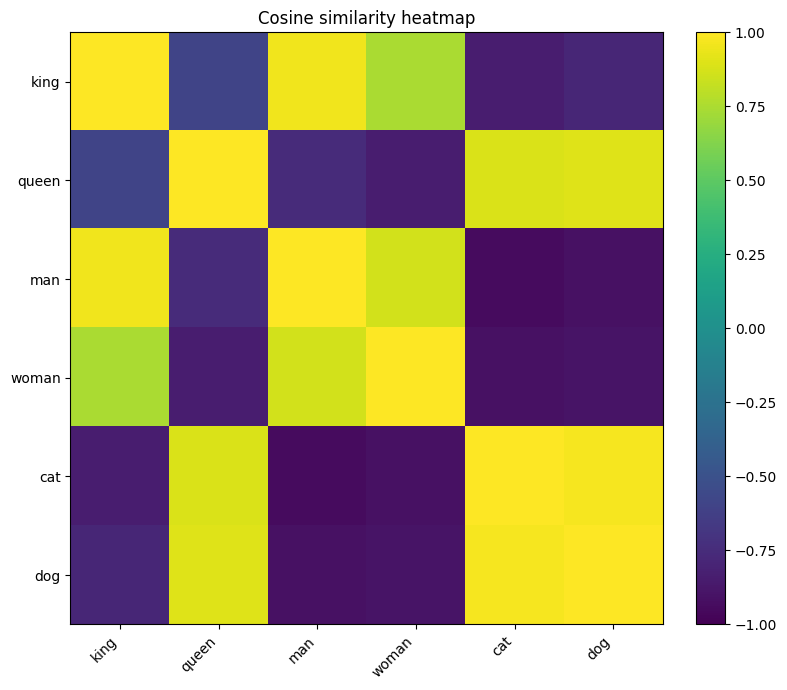

Nearest neighbors for: build



,neighbor,cosine_similarity
0,dock,0.966354
1,sufficient,0.966320
2,reforms,0.965443
3,terrain,0.965332
4,premiered,0.965159
5,lennon,0.965117
6,walker,0.964723
7,seek,0.964285
8,bears,0.964131
9,ranging,0.964077


In [5]:
# For this checkpoint, "build" gives a slightly more interpretable nearest-neighbor sample than "king".
my_query = "build"
my_analogy = ("man", "king", "woman")
my_heatmap_words = ["king", "queen", "man", "woman", "cat", "dog"]

print("\nHeatmap:")
try:
    plot_similarity_heatmap(my_heatmap_words, EMB, word2id)
except Exception as e:
    print(f"Heatmap failed: {e}")

if word2id is not None and my_query in word2id:
    print(f"Nearest neighbors for: {my_query}\n")
    display(pd.DataFrame(
        nearest_neighbors(
            my_query,
            EMB,
            word2id,
            id2word,
            top_k=TOP_K,
            normalized_embeddings=EMB_NORM,
        ),
        columns=["neighbor", "cosine_similarity"],
    ))
else:
    print(f"Word not found: {my_query}")





## Word analogy

Classic analogy query:

\[
b - a + c \approx ?
\]

Example: `man : king :: woman : queen`


In [6]:
analogy_examples = [
    ("man", "king", "woman"),
    ("paris", "france", "berlin"),
    ("boy", "prince", "girl"),
]

for a, b, c in analogy_examples:
    if word2id is None or any(w not in word2id for w in (a, b, c)):
        print(f"Skip analogy ({a}, {b}, {c}) because at least one word is missing from the vocab.")
        continue

    print(f"\n{a} : {b} :: {c} : ?")
    for word, score in analogy(
        a, b, c, EMB, word2id, id2word, top_k=TOP_K, normalized_embeddings=EMB_NORM
    ):
        print(f"  {word:<18} {score: .4f}")


man : king :: woman : ?
  form                0.9051
  so                  0.9016
  if                  0.9015
  up                  0.9011
  best                0.9007
  short               0.9005
  until               0.8997
  only                0.8993
  3                   0.8993
  due                 0.8992

paris : france :: berlin : ?
  certifications      0.9211
  depression          0.9167
  synopsis            0.9158
  legacy              0.9108
  commercial          0.9046
  era                 0.9020
  positive            0.9015
  tech                0.9009
  chart               0.9006
  xef                 0.8983

boy : prince :: girl : ?
  training            0.8575
  ali                 0.8565
  van                 0.8509
  shiva               0.8492
  flying              0.8483
  trees               0.8474
  priest              0.8468
  constructed         0.8463
  von                 0.8453
  chris               0.8450


## Similarity sanity checks

A few hand-picked word pairs can be useful as a quick semantic sanity check.


In [7]:
sanity_pairs = [
    ("cat", "dog"),
    ("car", "train"),
    ("paris", "france"),
    ("king", "queen"),
    ("cat", "democracy"),
    ("music", "science"),
]

sim_df = similarity_table(sanity_pairs, EMB, word2id)
sim_df.sort_values("cosine_similarity", ascending=False)

,word_1,word_2,cosine_similarity
0,cat,dog,0.975490
1,car,train,0.932901
5,music,science,0.527588
4,cat,democracy,0.455558
3,king,queen,-0.589000
2,paris,france,-0.868162


## PCA visualization

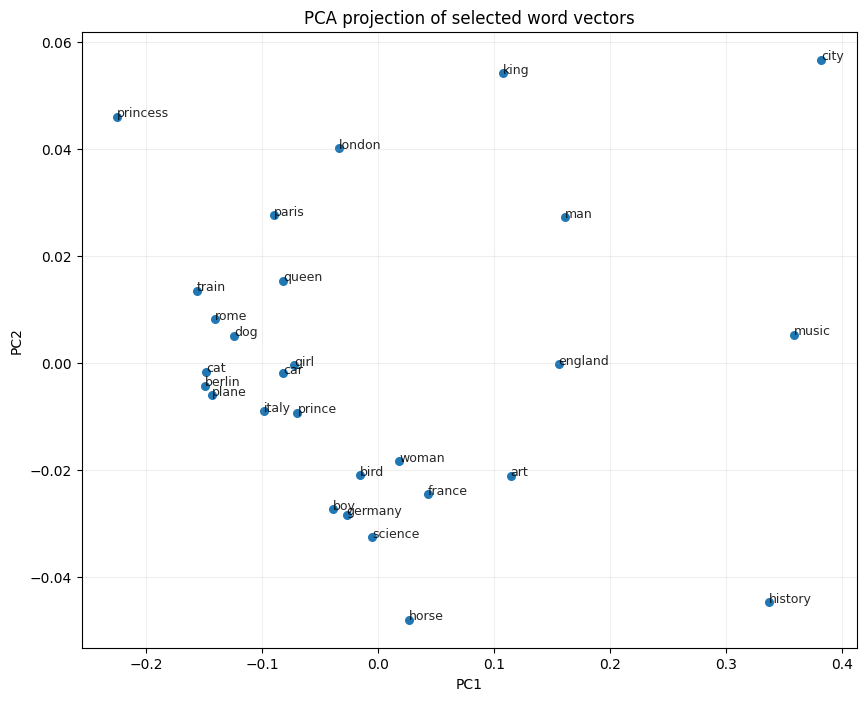

In [8]:
plot_pca(PCA_WORDS, EMB, word2id)

## t-SNE visualization

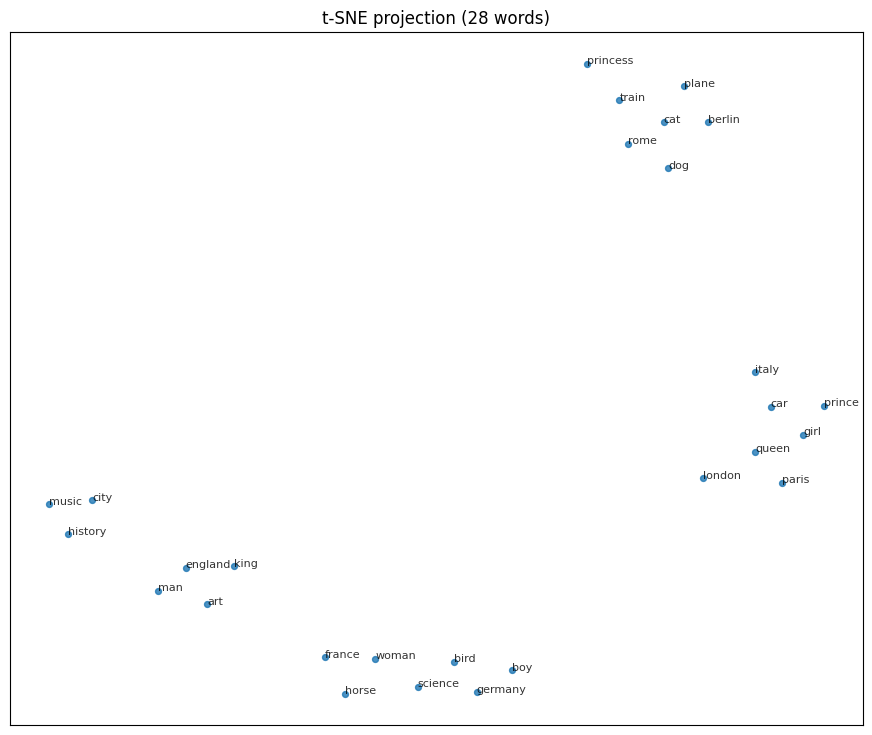

In [9]:
if word2id is None:
    raise ValueError("Need vocab for t-SNE visualization")

candidate_words = collect_existing_words(PCA_WORDS, word2id)
if len(candidate_words) < 20:
    candidate_words = maybe_pick_default_words(id2word, limit=TSNE_MAX_WORDS)

plot_tsne(
    candidate_words,
    EMB,
    word2id,
    max_words=TSNE_MAX_WORDS,
    random_state=TSNE_RANDOM_STATE,
)

## Cosine similarity heatmap

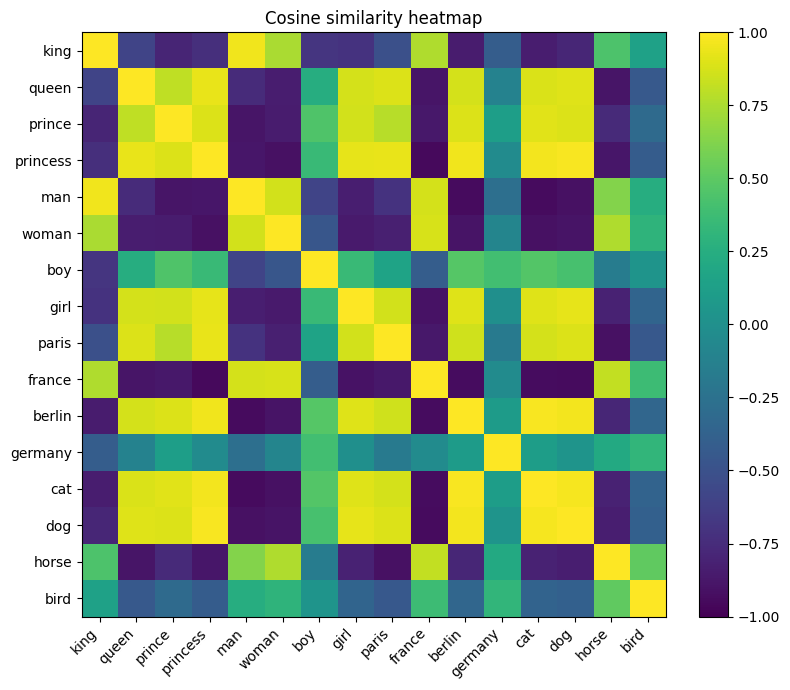

In [10]:
heatmap_words = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "paris", "france", "berlin", "germany",
    "cat", "dog", "horse", "bird",
]
plot_similarity_heatmap(heatmap_words, EMB, word2id)

## Nearest neighbors

This is the simplest qualitative check:  
for a query word, list the top cosine-nearest words in the learned embedding space.


In [11]:
query_words = [
    "king", "queen", "man", "woman",
    "paris", "france", "berlin", "germany",
    "cat", "dog", "music", "science",
]

available_queries = [w for w in query_words if word2id is not None and w in word2id]
if not available_queries:
    print("None of the default query words are in the vocab. Replace query_words with words from your corpus.")
else:
    for q in available_queries:
        print(f"\n[{q}]")
        for neighbor, score in nearest_neighbors(
            q, EMB, word2id, id2word, top_k=TOP_K, normalized_embeddings=EMB_NORM
        ):
            print(f"  {neighbor:<18} {score:.4f}")


[king]
  company            0.9862
  described          0.9843
  small              0.9833
  any                0.9827
  wrote              0.9822
  black              0.9818
  water              0.9810
  school             0.9801
  river              0.9796
  de                 0.9789

[queen]
  s.                 0.9530
  y                  0.9475
  europium           0.9469
  et                 0.9468
  van                0.9466
  voiced             0.9464
  von                0.9464
  isbn               0.9459
  odaenathus         0.9450
  results            0.9448

[man]
  and                0.9939
  with               0.9938
  ,                  0.9938
  the                0.9937
  for                0.9936
  in                 0.9936
  while              0.9936
  by                 0.9936
  also               0.9935
  he                 0.9935

[woman]
  production         0.9214
  attack             0.9211
  per                0.9210
  park               0.9200
  history      

## Appendix: helper utilities

To keep the demo notebook clean, helper functions are stored in a companion file in `src/` foler:

`demo_helpers.py`

The next cell shows where that file is loaded from.


In [12]:
from pathlib import Path
HELPER_FILE = Path("src/eval/demo_helpers.py").resolve()
print(HELPER_FILE)

C:\Users\User1\OneDrive - TU Eindhoven\Job\JetBrains\Hallucination Detection\src\eval\demo_helpers.py
